Intercept: 8149.779735682765
Slope: 196.03524229074895
MAE: 10719.530102790019
MSE: 127889149.79914235
RMSE: 11308.808504840037
R2 Score: 0.9890380728743592


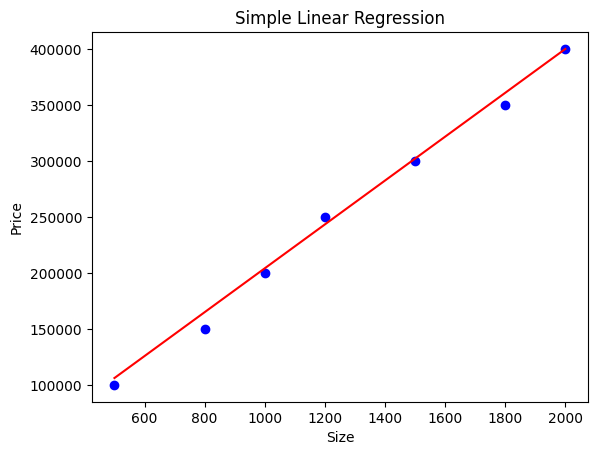

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Sample dataset
data = pd.DataFrame({
    'Size': [500, 800, 1000, 1200, 1500, 1800, 2000],
    'Price': [100000, 150000, 200000, 250000, 300000, 350000, 400000]
})

X = data[['Size']]
y = data['Price']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# Plot
plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Simple Linear Regression")
plt.show()

In [2]:
# Sample dataset
data = pd.DataFrame({
    'Size': [1000, 1500, 2000, 2500, 3000],
    'Bedrooms': [2, 3, 3, 4, 5],
    'Age': [10, 8, 5, 3, 1],
    'Price': [200000, 300000, 400000, 500000, 600000]
})

X = data[['Size', 'Bedrooms', 'Age']]
y = data['Price']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Results
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Intercept: 8.399848802830093
Coefficients: [199.99640006   0.5999892   -0.5999892 ]
R2 Score: nan
RMSE: 0.0


/Users/harshsareen/cm_col_f_1/probability/venv/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [ ]:
X_b = np.c_[np.ones((len(X), 1)), X]
Y = y.values.reshape(-1, 1)

# Normal Equation
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(Y)

print("Parameters using Normal Equation:")
print(theta)

Parameters using Normal Equation:
[[ 1.19750000e+07]
 [-3.94287109e+03]
 [-6.12500000e+05]
 [-7.50000000e+04]]


In [4]:
from sklearn.linear_model import Ridge, Lasso

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
print("Ridge Coefficients:", ridge.coef_)

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
print("Lasso Coefficients:", lasso.coef_)

Ridge Coefficients: [199.99562563   0.37445989  -0.82551386]
Lasso Coefficients: [199.99999982   0.          -0.        ]


In [5]:
import argparse
import pandas as pd
from sklearn.linear_model import LinearRegression
import joblib

parser = argparse.ArgumentParser()
parser.add_argument('--data_path', type=str)
args = parser.parse_args()

data = pd.read_csv(args.data_path)

X = data.drop('Price', axis=1)
y = data['Price']

model = LinearRegression()
model.fit(X, y)

joblib.dump(model, 'model.pkl')

usage: ipykernel_launcher.py [-h] [--data_path DATA_PATH]
ipykernel_launcher.py: error: unrecognized arguments: -f /Users/harshsareen/Library/Jupyter/runtime/kernel-8f3b42a7-e717-4007-bf5b-f33f11e2aa8c.json


SystemExit: 2

/Users/harshsareen/cm_col_f_1/probability/venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

ml_client = MLClient(
    DefaultAzureCredential(),
    subscription_id="<SUBSCRIPTION_ID>",
    resource_group_name="<RESOURCE_GROUP>",
    workspace_name="<WORKSPACE_NAME>"
)

job = ml_client.jobs.create_or_update({
    "command": "python train.py --data_path data.csv",
    "compute": "cpu-cluster",
    "environment": "AzureML-sklearn-1.0-ubuntu20.04-py38-cpu:1"
})

In [ ]:
from azure.ai.ml.entities import ManagedOnlineEndpoint, ManagedOnlineDeployment

endpoint = ManagedOnlineEndpoint(
    name="regression-endpoint",
    auth_mode="key"
)

ml_client.begin_create_or_update(endpoint)

deployment = ManagedOnlineDeployment(
    name="blue",
    endpoint_name="regression-endpoint",
    model="model.pkl",
    instance_type="Standard_DS3_v2",
    instance_count=1
)

ml_client.begin_create_or_update(deployment)

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [10]:
# Create dataset
data = pd.DataFrame({
    'Size': [800, 1000, 1200, 1500, 1800, 2000, 2200, 2500],
    'Bedrooms': [2, 2, 3, 3, 3, 4, 4, 5],
    'Age': [20, 15, 10, 8, 5, 3, 2, 1],
    'Price': [150000, 180000, 220000, 300000, 350000, 400000, 420000, 500000]
})

print(data.head())

   Size  Bedrooms  Age   Price
0   800         2   20  150000
1  1000         2   15  180000
2  1200         3   10  220000
3  1500         3    8  300000
4  1800         3    5  350000


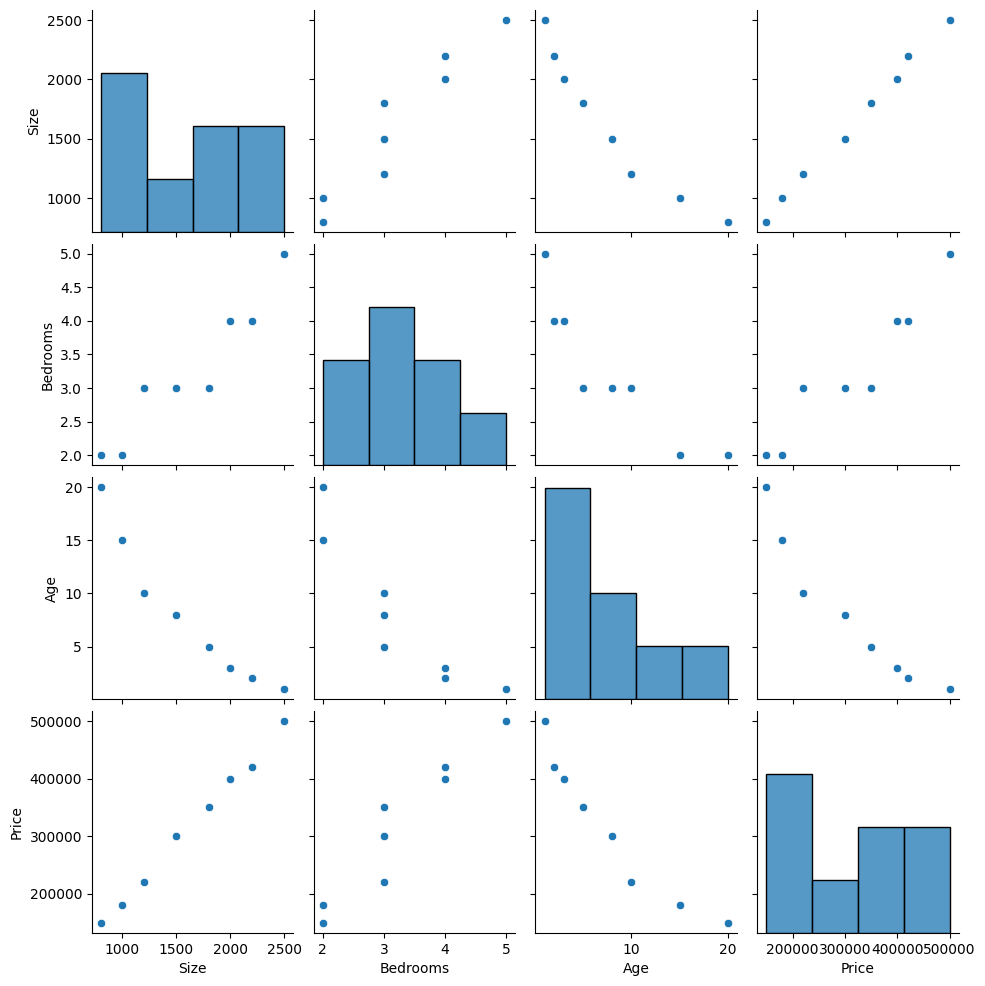

              Size  Bedrooms       Age     Price
Size      1.000000  0.951762 -0.957496  0.997696
Bedrooms  0.951762  1.000000 -0.903813  0.953791
Age      -0.957496 -0.903813  1.000000 -0.951693
Price     0.997696  0.953791 -0.951693  1.000000


In [11]:
sns.pairplot(data)
plt.show()

print(data.corr())

In [12]:
X = data[['Size', 'Bedrooms', 'Age']]
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
slr = LinearRegression()
slr.fit(X_train[['Size']], y_train)

y_pred_slr = slr.predict(X_test[['Size']])

print("SLR R2:", r2_score(y_test, y_pred_slr))

SLR R2: 0.9940151722377059


In [15]:
mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)

y_pred = mlr.predict(X_test_scaled)

print("Intercept:", mlr.intercept_)
print("Coefficients:", mlr.coef_)

Intercept: 323333.3333333333
Coefficients: [ 1.24879612e+05 -4.94112678e+01  8.26000431e+03]


In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 9537.2435325603
RMSE: 9591.901303559502
R2 Score: 0.9923963164779152


In [17]:
n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - (1-r2)*(n-1)/(n-p-1)
print("Adjusted R2:", adjusted_r2)

Adjusted R2: 1.0038018417610424


In [18]:
scores = cross_val_score(mlr, X_train_scaled, y_train, cv=5, scoring='r2')
print("Cross Validation R2 Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation R2 Scores: [0.27981859        nan        nan        nan        nan]
Average CV Score: nan


/Users/harshsareen/cm_col_f_1/probability/venv/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/harshsareen/cm_col_f_1/probability/venv/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/harshsareen/cm_col_f_1/probability/venv/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/harshsareen/cm_col_f_1/probability/venv/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [19]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

print("Ridge R2:", ridge.score(X_test_scaled, y_test))

Ridge R2: 0.9979809541823959


In [20]:
lasso = Lasso(alpha=1000)
lasso.fit(X_train_scaled, y_train)

print("Lasso R2:", lasso.score(X_test_scaled, y_test))

Lasso R2: 0.9929816877883884


In [27]:
# Simple Gradient Descent for SLR

X_gd = data['Size'].values
y_gd = data['Price'].values

m = 0
b = 0
learning_rate = 0.00000001
epochs = 1000
n = len(X_gd)

for _ in range(epochs):
    y_pred = m * X_gd + b
    dm = (-2/n) * sum(X_gd * (y_gd - y_pred))
    db = (-2/n) * sum(y_gd - y_pred)
    m -= learning_rate * dm
    b -= learning_rate * db

print("Gradient Descent Slope:", m)
print("Gradient Descent Intercept:", b)



Gradient Descent Slope: 195.18170585769516
Gradient Descent Intercept: 0.06383592265974823


In [28]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

ValueError: operands could not be broadcast together with shapes (2,) (8,) 

In [29]:
import joblib

joblib.dump(mlr, "house_price_model.pkl")

['house_price_model.pkl']

In [30]:
model_loaded = joblib.load("house_price_model.pkl")

sample = [[2000, 3, 5]]
sample_scaled = scaler.transform(sample)

prediction = model_loaded.predict(sample_scaled)
print("Predicted Price:", prediction[0])

Predicted Price: 392097.45762711857


/Users/harshsareen/cm_col_f_1/probability/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
